<a href="https://colab.research.google.com/github/tharindu33333/ME421-Mechanical-Systems-Lab-A2/blob/main/Controls/E_20_175_Controls.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Rigid body control

Reference: https://github.com/mugalan/intrinsic-rigid-body-control-estimation/blob/main/rigid-body-control/Twin_Rotor_Attitude_Tracking_DHSM.ipynb


Image Credits: Bhashitha Maduranga Nawaratne bhashitha614@gmail.com

#Task 01

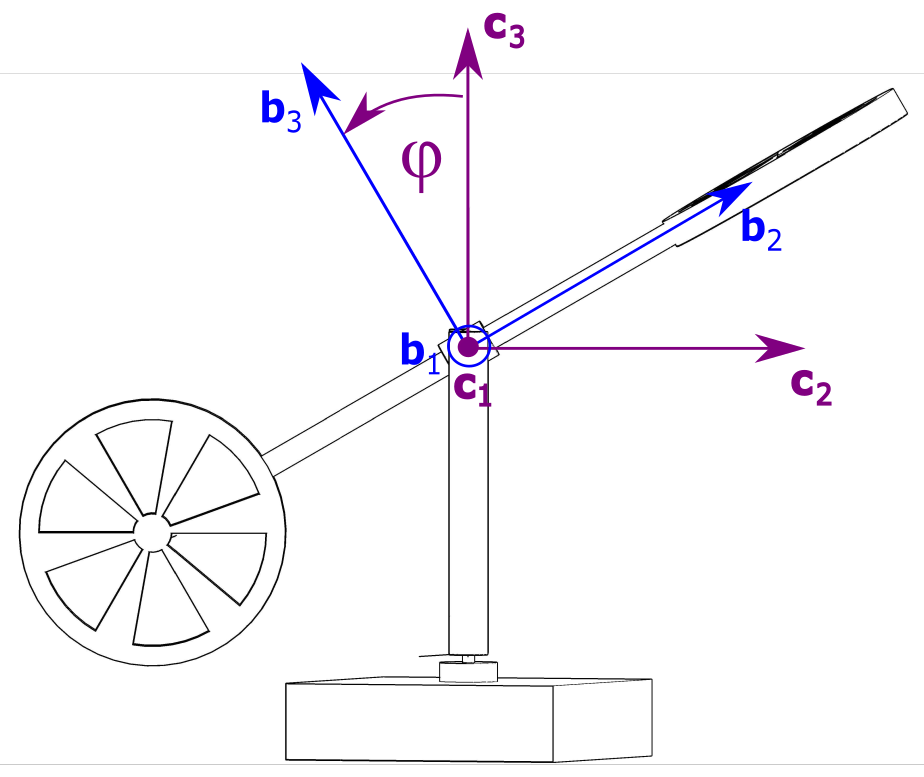

**1.1 Kinematic Derivation**

The system configuration is defined by two successive rotations: a yaw $\theta$ about the vertical axis $e_3$ and a pitch $\phi$ about the horizontal axis $c_1$.

1. Frame Definitions:Inertial frame: $e = \{e_1, e_2, e_3\}$.

Intermediate yaw frame: $c = e R_3(\theta)$.

Body frame: $b = c R_1(\phi) = e R$.

2. Rotation Matrix:
The combined rotation matrix $R \in SO(3)$ is:


$$R = R_3(\theta)R_1(\phi) = \begin{bmatrix} \cos\theta & -\sin\theta & 0 \\ \sin\theta & \cos\theta & 0 \\ 0 & 0 & 1 \end{bmatrix} \begin{bmatrix} 1 & 0 & 0 \\ 0 & \cos\phi & -\sin\phi \\ 0 & \sin\phi & \cos\phi \end{bmatrix}$$

3. Proving $\dot{R} = \hat{\omega}R$:

Differentiating the rotation: $\dot{R} = \dot{R}_3 R_1 + R_3 \dot{R}_1$.

Using the identities $\dot{R}_3 = R_3 \hat{\Omega}_3$ and $\dot{R}_1 = R_1 \hat{\Omega}_1$, where $\hat{\Omega}_i$ are skew-symmetric angular velocity matrices.

This leads to $\dot{R} = R \hat{\Omega}$, where $\Omega$ is the body angular velocity.

The spatial angular velocity is defined as $\omega = R\Omega$, which transforms the equation to the spatial frame: $\dot{R} = \hat{\omega}R$.


\
**1.2 Momentum Dynamics**

The spatial angular momentum $\pi$ is defined as:
$$\pi = R \mathbb{I} \Omega = R \mathbb{I} R^T \omega$$The rate of change of momentum is equal to the sum of external and control moments:
$$\dot{\pi} = \tau^e + \tau^u$$


\
**1.3 Manipulatable (Control) Torque**


The two rotors generate torques in the body frame of the form

$$
\tau_b^u =
\begin{bmatrix}
\cos\alpha & -\cos\beta \\
0 & 0 \\
\sin\alpha & -\sin\beta
\end{bmatrix}
\begin{bmatrix}
u_1 \\
u_2
\end{bmatrix}.
$$

Embedding this into $\mathbb{R}^3$ gives

$$
\tau_b^u =
\begin{bmatrix}
1 & 0 \\
0 & 0 \\
0 & 1
\end{bmatrix}
\begin{bmatrix}
\cos\alpha & -\cos\beta \\
\sin\alpha & -\sin\beta
\end{bmatrix}
\begin{bmatrix}
u_1 \\
u_2
\end{bmatrix}.
$$

Transforming to the spatial frame,

$$
\tau^u =
R
\begin{bmatrix}
1 & 0 \\
0 & 0 \\
0 & 1
\end{bmatrix}
\begin{bmatrix}
\cos\alpha & -\cos\beta \\
\sin\alpha & -\sin\beta
\end{bmatrix}
\begin{bmatrix}
u_1 \\
u_2
\end{bmatrix}.
$$



**1.4 Constraint Torque**

The device is constrained to prevent rotation about the body axis $b_2$.  

From the rigid body equation in the body frame,

$$
\mathbb{I}\dot{\Omega} + \Omega \times \mathbb{I}\Omega = \tau_b.
$$

Taking the second component gives

$$
T_2 = e_2^T\left(\Omega \times \mathbb{I}\Omega + \mathbb{I}\dot{\Omega}\right).
$$

Hence the constraint torque in the spatial frame is

$$
\tau^e = R
\begin{bmatrix}
0 \\
T_2 \\
0
\end{bmatrix}.
$$


**1.5 Final Model**

Therefore, the twin rotor system admits the compact representation

$$
\dot{R} = \widehat{\omega}R
$$

$$
\dot{\pi} = \tau^e + \tau^u
$$

$$
\omega = (\mathbb{I}^R)^{-1}\pi.
$$




#Task 02

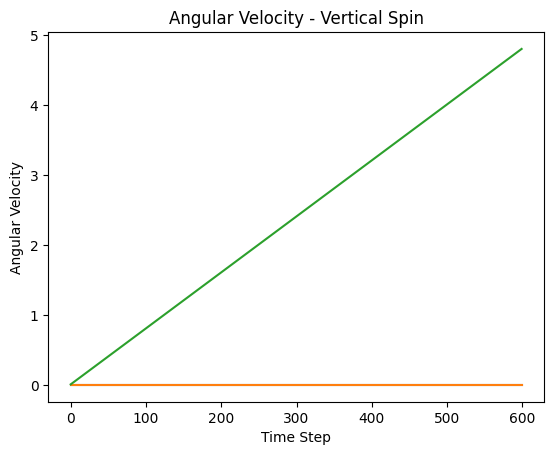

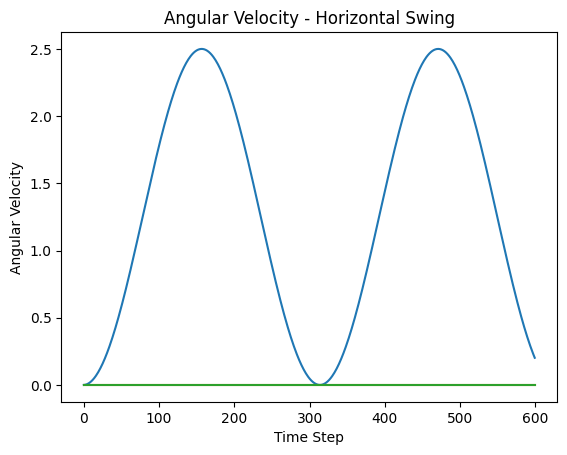

In [1]:

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

def hat(w):
    return np.array([[0, -w[2], w[1]],
                     [w[2], 0, -w[0]],
                     [-w[1], w[0], 0]])

def reorthonormalize(R):
    U, _, Vt = np.linalg.svd(R)
    return U @ Vt

def twin_rotor_torque(R, u1, u2, alpha, beta):
    tau_body = np.array([
        u1*np.cos(alpha) - u2*np.cos(beta),
        0.0,
        u1*np.sin(alpha) - u2*np.sin(beta)
    ])
    return R @ tau_body

def simulate(I, torque_function, dt=0.01, T=6.0):
    steps = int(T/dt)

    R = np.eye(3)
    omega = np.zeros(3)

    R_history = []
    omega_history = []

    for i in range(steps):
        t = i*dt

        tau = torque_function(t, R, omega)

        omega_dot = np.linalg.inv(I) @ (tau - np.cross(omega, I @ omega))
        omega = omega + dt*omega_dot

        R = R + dt*(hat(omega) @ R)
        R = reorthonormalize(R)

        R_history.append(R.copy())
        omega_history.append(omega.copy())

    return np.array(R_history), np.array(omega_history)

I = np.diag([0.02, 0.03, 0.05])

alpha = np.pi/2
beta  = -np.pi/2

def vertical_spin(t, R, omega):
    u1 = 0.04
    u2 = 0.0
    return twin_rotor_torque(R, u1, u2, alpha, beta)

R_spin, omega_spin = simulate(I, vertical_spin)

alpha = 0.0
beta  = 0.0

def horizontal_swing(t, R, omega):
    u1 = 0.05*np.sin(2*t)
    u2 = 0.0
    return twin_rotor_torque(R, u1, u2, alpha, beta)

R_swing, omega_swing = simulate(I, horizontal_swing)

def animate_motion(R_history, title):
    fig = plt.figure()
    ax = fig.add_subplot(projection='3d')

    ax.set_xlim([-1.5, 1.5])
    ax.set_ylim([-1.5, 1.5])
    ax.set_zlim([-1.5, 1.5])
    ax.set_title(title)

    body_axes = np.eye(3)
    lines = [ax.plot([], [], [], lw=3)[0] for _ in range(3)]

    def update(frame):
        R = R_history[frame]
        for i in range(3):
            vec = R @ body_axes[:, i]
            lines[i].set_data([0, vec[0]], [0, vec[1]])
            lines[i].set_3d_properties([0, vec[2]])
        return lines

    ani = FuncAnimation(fig, update, frames=len(R_history), interval=20)


plt.figure()
plt.plot(omega_spin)
plt.title("Angular Velocity - Vertical Spin")
plt.xlabel("Time Step")
plt.ylabel("Angular Velocity")
plt.show()

plt.figure()
plt.plot(omega_swing)
plt.title("Angular Velocity - Horizontal Swing")
plt.xlabel("Time Step")
plt.ylabel("Angular Velocity")
plt.show()


#Task 03

**3.1 Tracking Error Dynamics on $SO(3)$**

Let $R_r(t)$ be a desired trajectory and let $\omega_r(t)$ satisfy

$$
\widehat{\omega}_r = \dot{R}_r R_r^T.
$$

In line with the system, define the reference spatial angular momentum

$$
\pi_r \triangleq R_r \mathbb{I} R_r^T \omega_r.
$$

**3.2 Configuration Error**

Define the left-invariant configuration error

$$
R_e = R_r R^T.
$$

Differentiating,

$$
\dot{R}_e
= \dot{R}_r R^T + R_r \dot{R}^T.
$$

Using $\dot{R}_r = \widehat{\omega}_r R_r$ and
$\dot{R} = \widehat{\omega} R$, we obtain

$$
\dot{R}_e
=
\widehat{\omega}_r R_r R^T
-
R_r R^T \widehat{\omega}.
$$

Thus,

$$
\dot{R}_e
=
\widehat{\omega}_r R_e
-
R_e \widehat{\omega}.
$$

Multiplying on the right by $R_e^T$ gives

$$
\widehat{\omega}_e
\triangleq
\dot{R}_e R_e^T
=
\widehat{\omega}_r
-
R_e \widehat{\omega} R_e^T.
$$

Hence, using the vee map,

$$
\omega_e
=
\omega_r
-
R_e \omega.
$$


**3.3 Angular Momentum Error**

Define the angular momentum tracking error

$$
\pi_e
\triangleq
R \mathbb{I} R_r^T \omega_e.
$$

Substituting $\omega_e = \omega_r - R_e \omega$,

$$
\pi_e
=
R \mathbb{I} R_r^T (\omega_r - R_e \omega).
$$

Using $R_e = R_r R^T$ and rearranging,

$$
\pi_e
=
R \mathbb{I} R_r^T \omega_r
-
R \mathbb{I} R^T \omega.
$$

Recognizing

$$
\pi_r = R_r \mathbb{I} R_r^T \omega_r,
\qquad
\pi = R \mathbb{I} R^T \omega,
$$

we obtain

$$
\pi_e
=
R_e^T \pi_r
-
\pi.
$$



**3.4 Differentiation of $\pi_e$**

Differentiating,

$$
\dot{\pi}_e
=
\frac{d}{dt}(R_e^T \pi_r)
-
\dot{\pi}.
$$

Using
$$
\frac{d}{dt}(R_e^T \pi_r)
=
R_e^T \dot{\pi}_r
-
\widehat{\omega}_e R_e^T \pi_r,
$$

and noting that
$$
\widehat{\omega}_e x = \omega_e \times x,
$$

we obtain

$$
\dot{\pi}_e
=
R_e^T(\dot{\pi}_r - \omega_e \times \pi_r)
-
\dot{\pi}.
$$

From rigid body dynamics,

$$
\dot{\pi}_r
=
R_r \dot{\Pi}_r
+
\omega_r \times \pi_r.
$$

Substituting and simplifying using
$\omega_r = \omega_e + R_e \omega$,

$$
\dot{\pi}_e
=
R_e^T
\left(
R_r \dot{\Pi}_r
+
(\omega_r - \omega_e)\times \pi_r
\right)
-
\dot{\pi}.
$$

Since $R_e^T R_r = R$, this becomes

$$
\dot{\pi}_e
=
R \dot{\Pi}_r
+
\omega \times \pi_r
-
\dot{\pi}.
$$

**3.5 Error Dynamics**

Using the system dynamics

$$
\dot{\pi} = \tau_u + \tau_e,
$$

the tracking error dynamics are

$$
\dot{R}_e = \widehat{\omega}_e R_e,
$$

$$
\dot{\pi}_e
=
R \dot{\Pi}_r
+
\omega \times \pi_r
-
\tau_u
-
\tau_e.
$$



Using these error dynamics derive a PID controller for the tracking problem and simulate its performance.

#Task 04

Experimentally verify the stability properties of the controller derived in Task 03 using the experimental setup available in the applied mechanics lab.